## **Ejercicio 4. Construcción de la red bipartita autor-video**

---

## **Carga de los datos preparados en el ejercicio 2**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

SEMILLA = 123

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 170)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "data" / "processed"

comentarios = pd.read_csv(DIR_PROCESSED / "comentarios_limpio.csv", keep_default_na=False)
videos = pd.read_csv(DIR_PROCESSED / "videos_limpio.csv", keep_default_na=False)

comentarios["me_gusta"] = pd.to_numeric(comentarios.me_gusta)
videos["vistas"] = pd.to_numeric(videos.vistas)

titulo = videos.set_index("video_id").title.to_dict()
canal_por_video = videos.set_index("video_id").channel_name.to_dict()
categoria_por_video = videos.set_index("video_id").category.to_dict()
vistas_por_video = videos.set_index("video_id").vistas.to_dict()
nombre_autor = comentarios.set_index("author_channel_id").author_name.to_dict()

AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_SUAVE, REJILLA = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "font.size": 9, "legend.frameon": False,
})

print(f"[cargado]  comentarios -> {len(comentarios)} filas")
print(f"[cargado]  videos      -> {len(videos)} filas")

[cargado]  comentarios -> 406 filas
[cargado]  videos      -> 293 filas


---

## **4.1. Red bipartita no dirigida autor-video**

In [2]:
aristas = (
    comentarios.groupby(["author_channel_id", "video_id"])
    .size()
    .reset_index(name="peso")
)

red = nx.Graph()
red.add_nodes_from(comentarios.author_channel_id.unique(), tipo="autor", bipartite=0)
red.add_nodes_from(comentarios.video_id.unique(), tipo="video", bipartite=1)
red.add_edges_from(
    (fila.author_channel_id, fila.video_id, {"peso": int(fila.peso)})
    for fila in aristas.itertuples()
)

autores = [n for n, d in red.nodes(data=True) if d["tipo"] == "autor"]
videos_red = [n for n, d in red.nodes(data=True) if d["tipo"] == "video"]

print(f"nodos   : {red.number_of_nodes()}  ({len(autores)} autores, {len(videos_red)} videos)")
print(f"aristas : {red.number_of_edges()}")
print(f"bipartita: {nx.is_bipartite(red)}")

nodos   : 351  (332 autores, 19 videos)
aristas : 343
bipartita: True


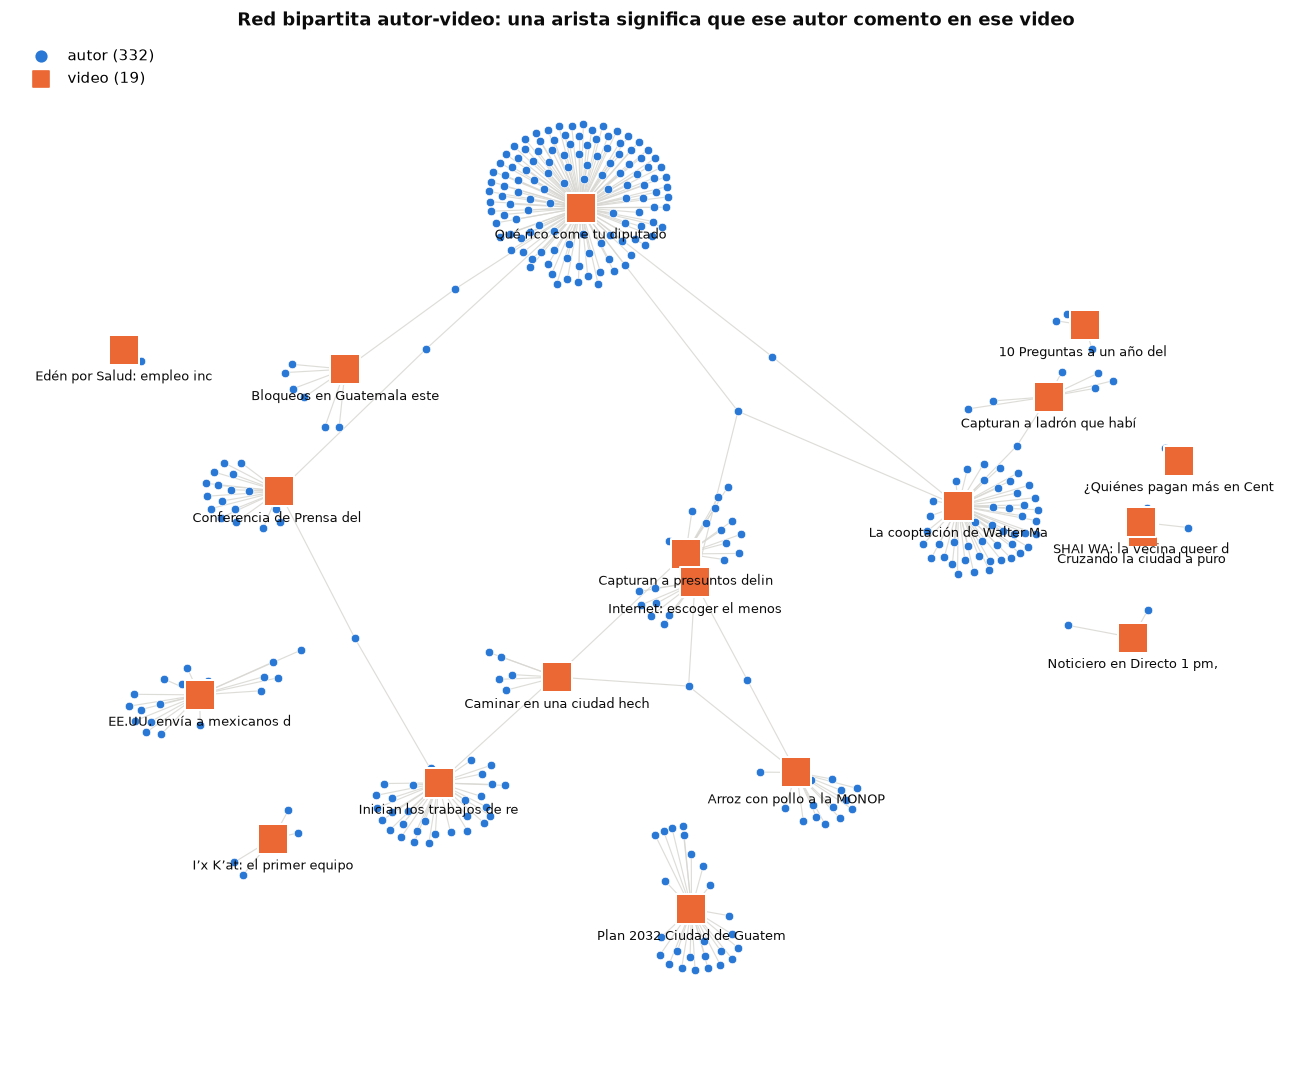

In [3]:
posicion = nx.spring_layout(red, seed=SEMILLA, k=0.32, iterations=180)
etiquetas_abajo = {n: (x, y - 0.055) for n, (x, y) in posicion.items()}

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(red, posicion, ax=ax, edge_color=REJILLA, width=0.7, alpha=0.85)
nx.draw_networkx_nodes(red, posicion, nodelist=autores, ax=ax,
                       node_color=AZUL, node_size=26, linewidths=0.4, edgecolors="white")
nx.draw_networkx_nodes(red, posicion, nodelist=videos_red, ax=ax,
                       node_color=NARANJA, node_shape="s", node_size=320,
                       linewidths=1.2, edgecolors="white")
nx.draw_networkx_labels(red, etiquetas_abajo, ax=ax,
                        labels={v: titulo[v][:26] for v in videos_red},
                        font_size=7.5, font_color=TINTA)

ax.scatter([], [], c=AZUL, s=40, label=f"autor ({len(autores)})")
ax.scatter([], [], c=NARANJA, marker="s", s=90, label=f"video ({len(videos_red)})")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Red bipartita autor-video: una arista significa que ese autor comento en ese video")
ax.axis("off")
plt.tight_layout()
plt.show()

---

## **4.2. Peso de las aristas según el número de comentarios**

In [4]:
pesos = nx.get_edge_attributes(red, "peso")
con_peso_mayor = {a: p for a, p in pesos.items() if p > 1}

print(f"aristas totales        : {len(pesos)}")
print(f"aristas con peso mayor a 1: {len(con_peso_mayor)}")
print(f"peso maximo            : {max(pesos.values())}")
print(f"suma de pesos          : {sum(pesos.values())}  (coincide con los {len(comentarios)} comentarios)")

aristas totales        : 343
aristas con peso mayor a 1: 40
peso maximo            : 6
suma de pesos          : 406  (coincide con los 406 comentarios)


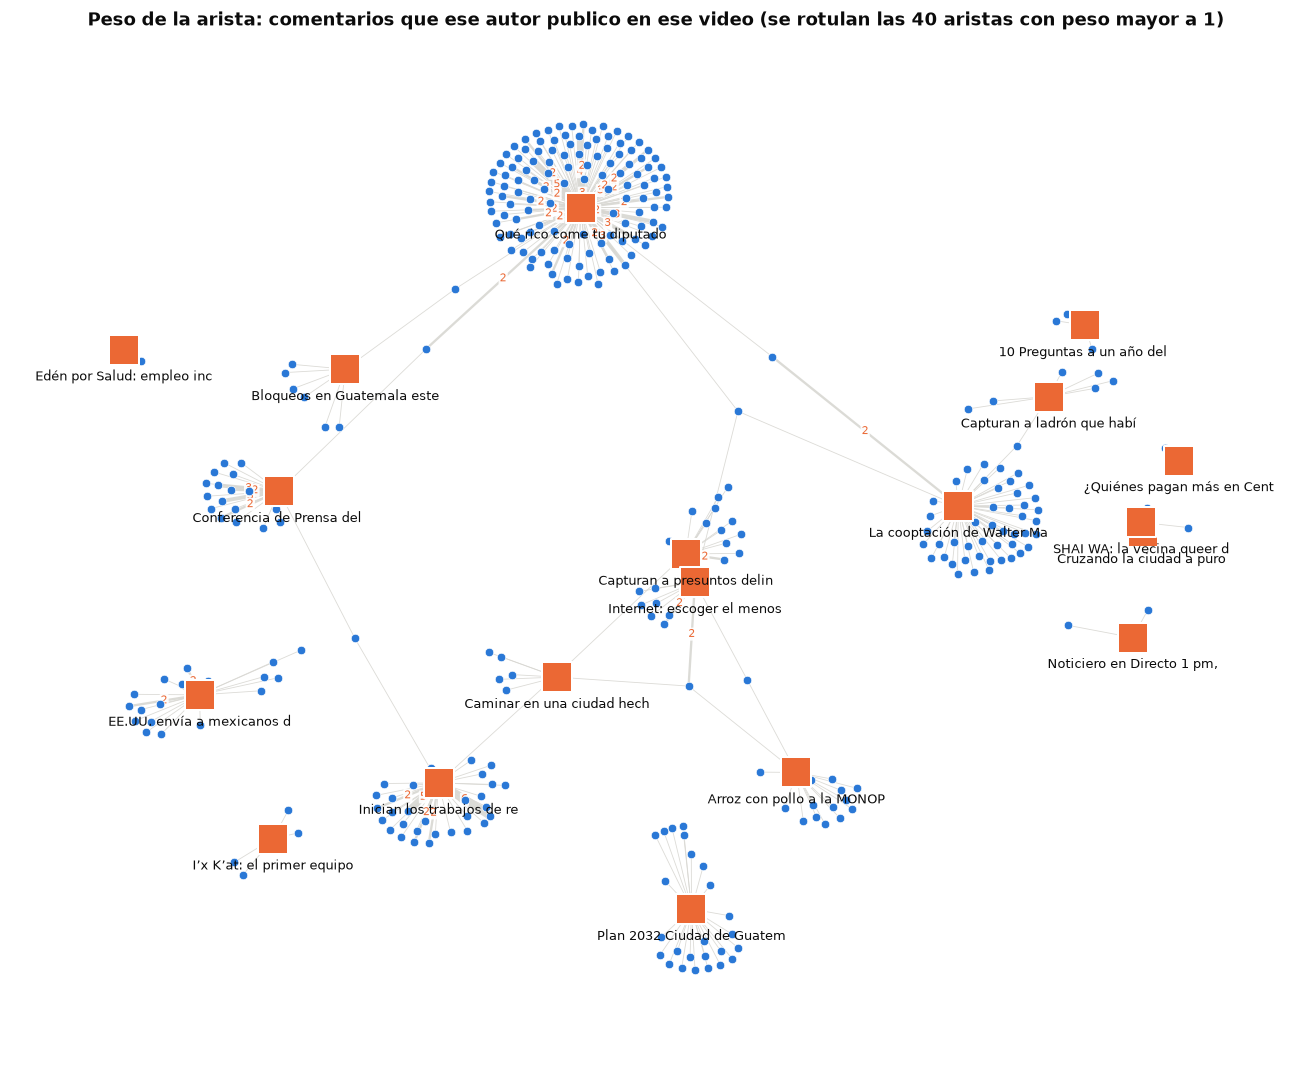

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(red, posicion, ax=ax, edge_color=REJILLA,
                       width=[0.5 + 0.9 * (pesos[a] - 1) for a in red.edges()], alpha=0.9)
nx.draw_networkx_nodes(red, posicion, nodelist=autores, ax=ax,
                       node_color=AZUL, node_size=26, linewidths=0.4, edgecolors="white")
nx.draw_networkx_nodes(red, posicion, nodelist=videos_red, ax=ax,
                       node_color=NARANJA, node_shape="s", node_size=320,
                       linewidths=1.2, edgecolors="white")
nx.draw_networkx_labels(red, etiquetas_abajo, ax=ax,
                        labels={v: titulo[v][:26] for v in videos_red},
                        font_size=7.5, font_color=TINTA)
nx.draw_networkx_edge_labels(red, posicion, ax=ax, edge_labels=con_peso_mayor,
                             font_size=6.5, font_color=NARANJA, rotate=False,
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.9))

ax.set_title("Peso de la arista: comentarios que ese autor publico en ese video "
             "(se rotulan las 40 aristas con peso mayor a 1)")
ax.axis("off")
plt.tight_layout()
plt.show()

---

## **4.3. Tabla de nodos y tabla de aristas**

In [6]:
grado_ponderado = dict(red.degree(weight="peso"))
comentarios_por_autor = comentarios.groupby("author_channel_id").size()
me_gusta_por_autor = comentarios.groupby("author_channel_id").me_gusta.sum()
autores_por_video = comentarios.groupby("video_id").author_channel_id.nunique()

tabla_nodos = pd.DataFrame([
    {
        "id": nodo,
        "tipo": datos["tipo"],
        "etiqueta": nombre_autor.get(nodo) if datos["tipo"] == "autor" else titulo.get(nodo),
        "grado": red.degree(nodo),
        "grado_ponderado": grado_ponderado[nodo],
        "canal": None if datos["tipo"] == "autor" else canal_por_video.get(nodo),
        "categoria": None if datos["tipo"] == "autor" else categoria_por_video.get(nodo),
        "vistas": None if datos["tipo"] == "autor" else vistas_por_video.get(nodo),
        "me_gusta_recibidos": int(me_gusta_por_autor.get(nodo, 0)) if datos["tipo"] == "autor" else None,
    }
    for nodo, datos in red.nodes(data=True)
]).sort_values(["tipo", "grado_ponderado"], ascending=[True, False]).reset_index(drop=True)

print(f"TABLA DE NODOS: {len(tabla_nodos)} filas")
tabla_nodos

TABLA DE NODOS: 351 filas


,id,tipo,etiqueta,grado,grado_ponderado,canal,categoria,vistas,me_gusta_recibidos
0,UCi2KiZq63sRq8Mfbcp-MelQ,autor,@eugeneramirez4405,1,6,NaN,NaN,NaN,1.0
1,UCyJhqmMbsvjpoarBBStA2kg,autor,@Murmullodelbarrio,1,6,NaN,NaN,NaN,14.0
2,UC5H8ASmMC9WrURmzeB4ySog,autor,@ManuelEdran,1,5,NaN,NaN,NaN,6.0
3,UCV3fr-YOixFKCZBbJP1-X4w,autor,@albertoshernandez5251,1,5,NaN,NaN,NaN,17.0
4,UCvcu1kR8xMYy_I1Ty-2mV2Q,autor,@hashojea7348,3,4,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...
346,3Nfp9h5avBI,video,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",2,2,Noticiero Guatevisión 13 Hrs.,News & Politics,573.0,NaN
347,X_FAIef8qlE,video,Cruzando la ciudad a puro Transmetro,1,1,Quorum,News & Politics,1140.0,NaN
348,zweosulrwA8,video,Edén por Salud: empleo inclusivo para personas...,1,1,Quorum,Nonprofits & Activism,52.0,NaN
349,UhL9y3KUl8E,video,SHAI WA: la vecina queer de Casa Presidencial,1,1,Quorum,News & Politics,1755.0,NaN


In [7]:
tabla_aristas = aristas.rename(
    columns={"author_channel_id": "origen_autor", "video_id": "destino_video"}
).assign(
    autor=lambda d: d.origen_autor.map(nombre_autor),
    video=lambda d: d.destino_video.map(titulo),
    canal=lambda d: d.destino_video.map(canal_por_video),
)[["origen_autor", "destino_video", "peso", "autor", "video", "canal"]].sort_values(
    "peso", ascending=False
).reset_index(drop=True)

print(f"TABLA DE ARISTAS: {len(tabla_aristas)} filas")
tabla_aristas

TABLA DE ARISTAS: 343 filas


,origen_autor,destino_video,peso,autor,video,canal
0,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6,@eugeneramirez4405,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo
1,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6,@Murmullodelbarrio,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala
2,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5,@albertoshernandez5251,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala
3,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5,@ManuelEdran,Qué rico come tu diputado,Quorum
4,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4,@ErvinLeonardoCarreraLatín,Qué rico come tu diputado,Quorum
...,...,...,...,...,...,...
338,UCNiMNUJvaRJb0_QLClqwVnA,TT4qJ5FXHYE,1,@Santiago.Nolasco,I’x K’at: el primer equipo guatemalteco de pel...,Quorum
339,UCN6qbfPSzFtjhqUDZ3Cv3CQ,n8iP75gIpmw,1,@carlosmedranovelasquez6380,Qué rico come tu diputado,Quorum
340,UCN2N_wYOw6fMwCeSzdXLPIw,PjmxCj-a9Hg,1,@danielantoniogonzalezflore4901,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala
341,UCLh1Kde4_vI1sTZBkTNP7RQ,is3Mk5oC19g,1,@JoelReynoso-d4r,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala


In [8]:
tabla_nodos.to_csv(DIR_PROCESSED / "red_nodos.csv", index=False)
tabla_aristas.to_csv(DIR_PROCESSED / "red_aristas.csv", index=False)

print(f"[guardado]  red_nodos.csv   -> {len(tabla_nodos)} filas")
print(f"[guardado]  red_aristas.csv -> {len(tabla_aristas)} filas")

[guardado]  red_nodos.csv   -> 351 filas
[guardado]  red_aristas.csv -> 343 filas


---

## **4.4. Red completa, incluyendo los videos sin participación observada**

In [9]:
red_completa = red.copy()
sin_comentarios = [v for v in videos.video_id if v not in red_completa]
red_completa.add_nodes_from(sin_comentarios, tipo="video", bipartite=1)

videos_completos = [n for n, d in red_completa.nodes(data=True) if d["tipo"] == "video"]

print(f"nodos   : {red_completa.number_of_nodes()}  ({len(autores)} autores, {len(videos_completos)} videos)")
print(f"aristas : {red_completa.number_of_edges()}")
print(f"videos aislados (grado 0): {len(sin_comentarios)}")
print(f"componentes conexas      : {nx.number_connected_components(red_completa)}")

nodos   : 625  (332 autores, 293 videos)
aristas : 343
videos aislados (grado 0): 274
componentes conexas      : 284


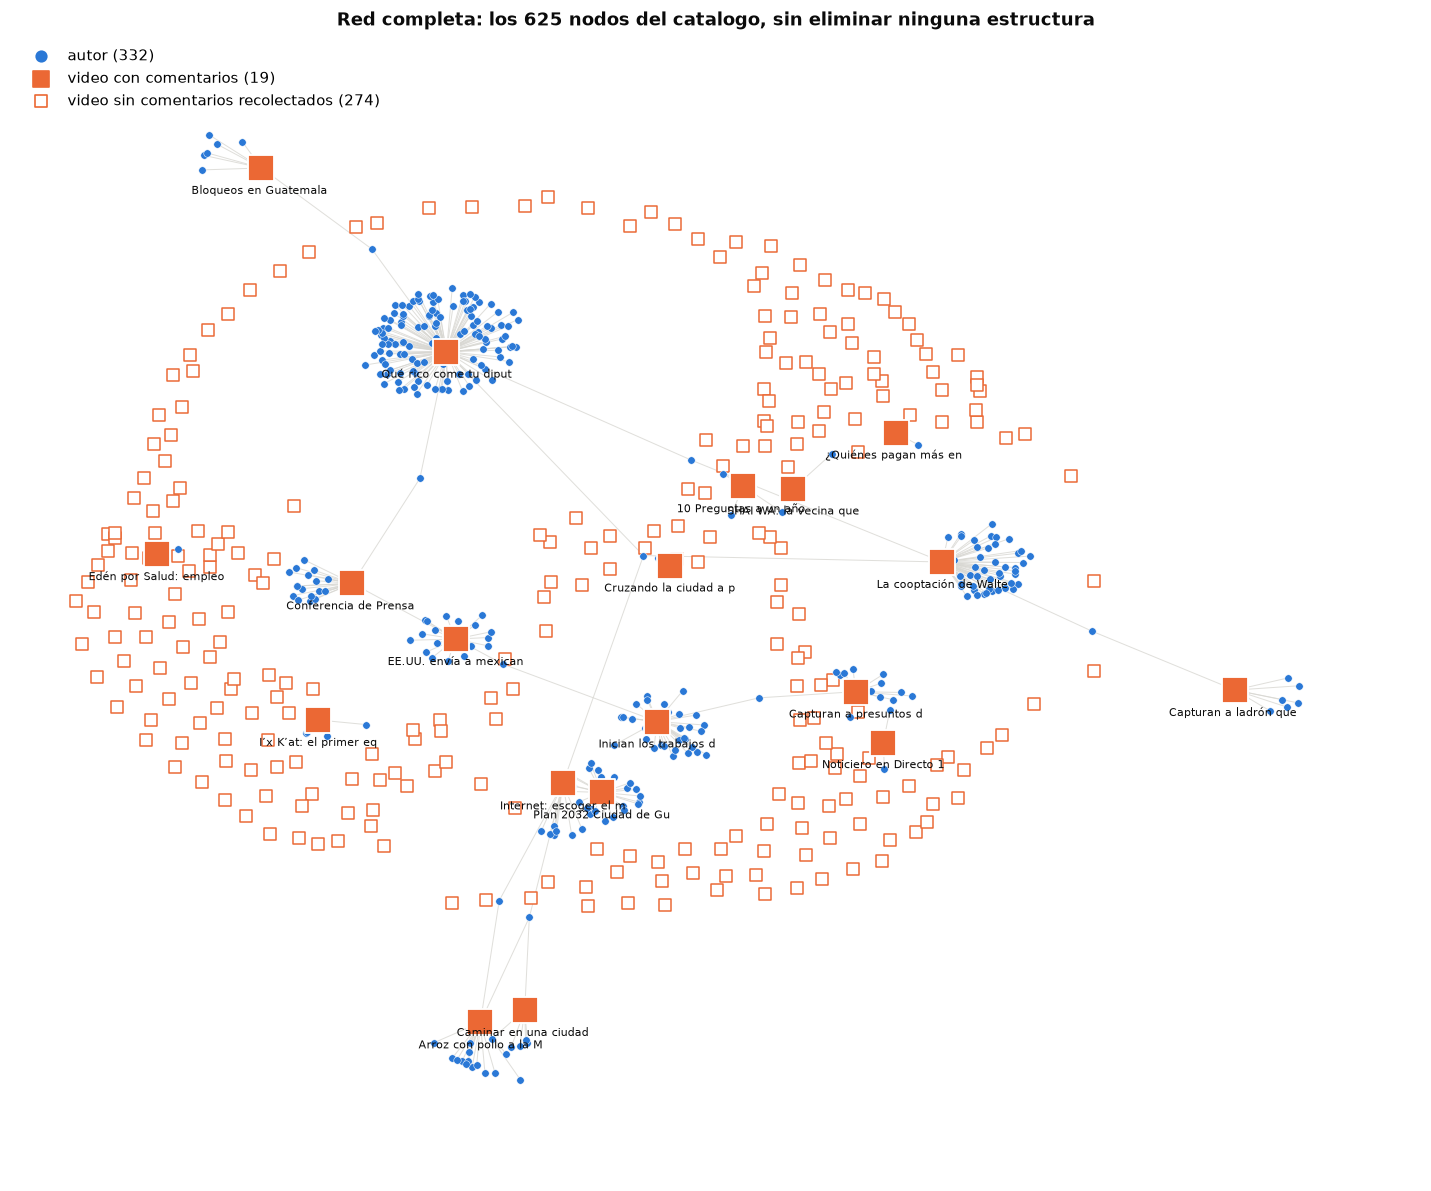

In [10]:
posicion_completa = nx.spring_layout(red_completa, seed=SEMILLA, k=0.15, iterations=120)
etiquetas_completa = {n: (x, y - 0.045) for n, (x, y) in posicion_completa.items()}

conectados = [v for v in videos_completos if red_completa.degree(v) > 0]

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(red_completa, posicion_completa, ax=ax, edge_color=REJILLA, width=0.6, alpha=0.8)
nx.draw_networkx_nodes(red_completa, posicion_completa, nodelist=sin_comentarios, ax=ax,
                       node_color="white", node_shape="s", node_size=48,
                       linewidths=0.9, edgecolors=NARANJA)
nx.draw_networkx_nodes(red_completa, posicion_completa, nodelist=autores, ax=ax,
                       node_color=AZUL, node_size=20, linewidths=0.3, edgecolors="white")
nx.draw_networkx_nodes(red_completa, posicion_completa, nodelist=conectados, ax=ax,
                       node_color=NARANJA, node_shape="s", node_size=260,
                       linewidths=1.1, edgecolors="white")
nx.draw_networkx_labels(red_completa, etiquetas_completa, ax=ax,
                        labels={v: titulo[v][:22] for v in conectados},
                        font_size=6.5, font_color=TINTA)

ax.scatter([], [], c=AZUL, s=40, label=f"autor ({len(autores)})")
ax.scatter([], [], c=NARANJA, marker="s", s=90, label=f"video con comentarios ({len(conectados)})")
ax.scatter([], [], facecolor="white", edgecolor=NARANJA, marker="s", s=60,
           label=f"video sin comentarios recolectados ({len(sin_comentarios)})")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Red completa: los 625 nodos del catalogo, sin eliminar ninguna estructura")
ax.axis("off")
plt.tight_layout()
plt.show()

---

## **4.5. Significado de una arista**

Una arista representa la conexión entre dos nodos, y en esta red conecta a un autor con un video en
el que dejó al menos un comentario; su peso es la cantidad de comentarios que ese autor publicó en
ese video.

Cabe mencionar que la arista no dice nada más que eso. Dos autores unidos al mismo video coincidieron
en el espacio de comentarios, lo cual no implica amistad, conversación directa entre ellos ni que sus comentarios
vayan en la misma línea.